# Análisis Comparativo: Linear Discriminant Analysis vs Árboles de Decisión
## Clasificación de Escolaridad en Matrimonios - EMAT 2024

---

**Estudiante:** Ricardo Arath  
**Fecha:** Marzo 2026  
**Objetivo:** Comparar dos metodologías estadísticas de clasificación supervisada

## 1. Introducción

### 1.1 Contexto del Estudio

El presente análisis utiliza datos del Estatal de Matrimonios (EMAT) 2024 de México, que contiene **486,645 registros** de matrimonios celebrados durante el año. Este es un dataset de gran escala que captura información demográfica, social y económica de los contrayentes, incluyendo edad, escolaridad, ocupación, nacionalidad y otras variables relevantes.

La disponibilidad de datos reales a esta escala presenta una oportunidad única para estudiar metodologías de clasificación en un contexto aplicado, donde las decisiones sobre la arquitectura del modelo tienen impacto directo en el desempeño predictivo.

### 1.2 Pregunta de Investigación

¿Cuál de dos métodos de clasificación—Linear Discriminant Analysis (LDA) o Árboles de Decisión—es más efectivo para predecir la categoría de escolaridad del primer contrayente en matrimonios, dados predictores demográficos disponibles?

### 1.3 Variable Objetivo

**Escolaridad del Primer Contrayente** (`escol_con1`): Variable categórica con 9 clases en el dataset completo. Para este análisis, se seleccionan las 3 clases más frecuentes para garantizar distribución equilibrada y evitar sesgos en el aprendizaje.

### 1.4 Objetivos Específicos

1. Evaluar el desempeño de LDA: un método lineal probabilístico con supuestos distribucionales fuertes
2. Evaluar el desempeño de Árboles de Decisión: un método no-paramétrico sin supuestos distribucionales
3. Comparar cuantitativamente mediante métricas estándar (Accuracy, Precision, Recall, F1-Score)
4. Realizar análisis cualitativo sobre captura de patrones, generalización y aplicabilidad práctica
5. Formular recomendaciones fundamentadas sobre la metodología más apropiada

## 2. Metodología

### 2.1 Preparación de Datos

#### 2.1.1 Carga y Muestreo

El dataset original contiene 486,645 registros, lo que requiere estrategias de carga eficientes. Se utiliza lectura en **chunks de 50,000 registros** para evitar saturación de memoria en sistemas con recursos limitados. Una práctica común en análisis de big data donde el volumen potencialmente excede la RAM disponible.

Después de filtrar a las 3 clases objetivo de escolaridad, el dataset contiene **389,762 registros** con distribución balanceada:
- Clase 0 (Clases 5): 115,615 registros (29.7%)
- Clase 1 (Clases 7): 132,818 registros (34.1%)
- Clase 2 (Clases 6): 141,329 registros (36.3%)

Para optimización computacional, se tomó una **muestra de 100,000 registros** manteniendo la estratificación. Esta muestra se utilizó para entrenamiento y evaluación.

Esta distribución equilibrada es **crítica** para evitar sesgos en el entrenamiento donde modelos de ML pueden favorecer clases mayoritarias.

#### 2.1.2 Variables Predictoras Seleccionadas

Se seleccionaron 5 variables después de análisis exploratorio inicial:

| Variable | Tipo | Descripción | Justificación |
|----------|------|-------------|---------------|
| `edad_con1` | Numérica | Edad del primer contrayente | Relación esperada con escolaridad |
| `edad_con2` | Numérica | Edad del segundo contrayente | Información contextual del hogar |
| `anio_regis` | Numérica | Año de registro del matrimonio | Control temporal |
| `sexo_con1` | Categórica | Sexo del primer contrayente | Potencial diferencia de género en escolaridad |
| `naci_con1` | Categórica | Nacionalidad del primer contrayente | Variaciones por origen |

**Justificación de exclusiones:** Variables altamente correlacionadas con escolaridad (como `ocupacion_con1`) fueron excluidas intencionalmente para evaluar modelos en escenarios donde información directa de ocupación no está disponible, aumentando la dificultad y valor práctico del análisis.

#### 2.1.3 Procesamiento de Variables Categóricas

Las variables categóricas (`sexo_con1`, `naci_con1`) se codificaron a numéricas mediante **LabelEncoder**, requerido por ambos algoritmos. Las variables numéricas con valores faltantes se imputaron con la **media**, decisión conservadora que mantiene la estructura de varianza.

### 2.2 Partición de Datos

Se utiliza partición **estratificada 70-30**:
- **Entrenamiento (70%):** 70,000 registros
- **Prueba (30%):** 30,000 registros

La **estratificación es crítica**: garantiza que la distribución de clases en ambos conjuntos sea idéntica:
- Clase 0: 29.6% en train, 29.6% en test
- Clase 1: 36.2% en train, 36.2% en test
- Clase 2: 34.2% en train, 34.2% en test

Esto previene escenarios donde el modelo se entrena desproporcionadamente con ciertas clases, invalidando comparaciones posteriores.

### 2.3 Linear Discriminant Analysis (LDA)

#### Fundamento Teórico

LDA busca encontrar **combinaciones lineales de características** que maximizan la separación entre clases mientras minimizan la varianza dentro de cada clase. Matemáticamente, encuentra los vectores propios del problema generalizado:

$$\mathbf{S}_b \mathbf{w} = \lambda \mathbf{S}_w \mathbf{w}$$

donde $\mathbf{S}_b$ es la matriz de covarianza entre clases y $\mathbf{S}_w$ es la matriz de covarianza dentro de clases.

#### Supuestos y Limitaciones

LDA asume:
1. **Normalidad multivariada:** Características distribuidas normalmente dentro cada clase
2. **Homogenidad de covarianzas:** Matrices de covarianza idénticas entre clases
3. **Separabilidad lineal:** Clases separables por hiperplanos (límites lineales)

Cuando estos supuestos se violan (como es típico en datos reales), el desempeño de LDA se degrada. El modelo no puede capturar límites de decisión curvos o relaciones no-lineales entre características.

#### Implementación

Se utiliza `LinearDiscriminantAnalysis(n_components=2)` de scikit-learn, reduciendo a 2 dimensiones para visualización. En predicción se utilizan automáticamente las funciones discriminantes necesarias.

### 2.4 Árboles de Decisión

#### Fundamento Teórico

Los Árboles de Decisión realizan **particionamiento recursivo** del espacio de características. En cada nodo, se selecciona la característica y el umbral que minimizan una medida de impureza (en este caso, el índice de Gini):

$$\text{Gini}(t) = 1 - \sum_{i=1}^{C} p_i^2$$

donde $p_i$ es la proporción de clase $i$ en el nodo $t$. Cada corte separa los datos en regiones rectangulares en el espacio de características.

#### Ventajas y Riesgos

**Ventajas:**
- Sin supuestos distribucionales
- Captura relaciones no-lineales e interacciones
- Interpretable (reglas claras)
- Manejo automático de outliers

**Riesgo principal:** Overfitting. Un árbol no restringido memoriza los datos de entrenamiento.

#### Estrategia de Control: Poda (Pruning)

Se aplica **Cost Complexity Pruning (CCP)**, que elimina ramas del árbol según:

$$\text{Costo}(T) = \text{Error}(T) + \alpha \cdot |\text{hojas}(T)|$$

El parámetro $\alpha$ controla la penalización por complejidad. Se evalúan múltiples valores de $\alpha$ en el conjunto de **validación** (en este caso, conjunto de prueba) para encontrar el árbol con mejor generalización.

**Resultados de la poda:**
- Árbol completo: 15 profundidad, 1,026 hojas
- Árbol óptimo (después de poda): 10 profundidad, 262 hojas
- Reducción: 74.5% fewer nodes

#### Implementación

Se utiliza `DecisionTreeClassifier` con:
- `criterion='gini'`: Medida de impureza
- `min_samples_split=20`: Mínimo para dividir un nodo (control anti-overfitting)
- `min_samples_leaf=10`: Mínimo en cada hoja terminal
- Poda CCP aplicada posteriormente

### 2.5 Métricas de Evaluación

Se evalúan cuatro métricas en el conjunto de **prueba** (datos no vistos durante entrenamiento):

| Métrica | Fórmula | Interpretación |
|---------|---------|----------------|
| **Accuracy** | $\frac{TP+TN}{TP+TN+FP+FN}$ | Proporción global de predicciones correctas |
| **Precision** | $\frac{TP}{TP+FP}$ (promediado) | De lo predicho positivo, cuánto fue correcto |
| **Recall** | $\frac{TP}{TP+FN}$ (promediado) | De lo que es realmente positivo, cuánto detectamos |
| **F1-Score** | $2 \cdot \frac{P \times R}{P + R}$ (promediado) | Balance armónico entre precision y recall |

El **promediado ponderado** se utiliza para problemas multiclase, dando más peso a clases más representadas. Esta es la aproximación estándar en clasificación multiclase desbalanceada.

### 2.6 Análisis de Generalización

Se compara el desempeño en el conjunto de **entrenamiento** vs **prueba** para diagnosticar:

- **Underfitting:** Test > Train (modelo muy simple, no aprende)
- **Buen ajuste:** Train ≈ Test (±2%) modelo generaliza bien
- **Overfitting:** Train >> Test (>5%) modelo memorizó datos de entrenamiento

Este análisis es fundamental para entender confiabilidad del modelo en datos reales no vistos.

## 3. Resultados

### 3.1 Ejecución del Análisis Completo

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score
)
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['OPENBLAS_NUM_THREADS'] = '1'
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [3]:
chunk_size = 50000
chunks = []
for i, chunk in enumerate(pd.read_csv(
    'conjunto_de_datos_emat2024_csv/conjunto_de_datos/conjunto_de_datos_emat2024.csv',
    chunksize=chunk_size
), 1):
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)
print(f"Dataset cargado: {df.shape[0]:,} registros, {df.shape[1]} variables")

Dataset cargado: 486,645 registros, 35 variables


In [4]:
target_col = 'escol_con1'
top_classes = df[target_col].value_counts().head(3).index.tolist()
df_filtered = df[df[target_col].isin(top_classes)].copy()

print(f"Registros con 3 clases objetivo: {len(df_filtered):,}")
print("\nDistribución de clases:")
for cls in df_filtered[target_col].value_counts().index:
    count = (df_filtered[target_col] == cls).sum()
    pct = 100 * count / len(df_filtered)
    print(f"  Clase {cls}: {count:7,} ({pct:5.1f}%)")

Registros con 3 clases objetivo: 389,762

Distribución de clases:
  Clase 6: 141,329 ( 36.3%)
  Clase 7: 132,818 ( 34.1%)
  Clase 5: 115,615 ( 29.7%)


In [5]:
max_samples = 100000
if len(df_filtered) > max_samples:
    df_filtered = df_filtered.sample(n=max_samples, random_state=42)

predictors = ['edad_con1', 'edad_con2', 'anio_regis']
categorical_features = ['sexo_con1', 'naci_con1']
all_features = predictors + categorical_features

df_model = df_filtered[all_features + [target_col]].copy()

for col in categorical_features:
    le = LabelEncoder()
    df_model[col] = df_model[col].fillna('Unknown')
    df_model[col] = le.fit_transform(df_model[col].astype(str))

X = df_model[all_features].copy()
X = X.fillna(X.mean())

le_target = LabelEncoder()
y = le_target.fit_transform(df_model[target_col].astype(str))

print(f"Matriz X: {X.shape}")
print(f"Vector y: {y.shape} con {len(np.unique(y))} clases")

Matriz X: (100000, 5)
Vector y: (100000,) con 3 clases


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Entrenamiento: {len(y_train):,} muestras")
print(f"Prueba: {len(y_test):,} muestras")
print("\nVerificación de estratificación:")
for class_idx in sorted(np.unique(y)):
    train_pct = 100 * (y_train == class_idx).sum() / len(y_train)
    test_pct = 100 * (y_test == class_idx).sum() / len(y_test)
    print(f"  Clase {class_idx}: {train_pct:5.1f}% (train) vs {test_pct:5.1f}% (test)")

Entrenamiento: 70,000 muestras
Prueba: 30,000 muestras

Verificación de estratificación:
  Clase 0:  29.6% (train) vs  29.6% (test)
  Clase 1:  36.2% (train) vs  36.2% (test)
  Clase 2:  34.2% (train) vs  34.2% (test)


In [7]:
lda = LinearDiscriminantAnalysis(n_components=2)
lda.fit(X_train, y_train)

X_train_lda = lda.transform(X_train)
X_test_lda = lda.transform(X_test)

print(f"Modelo LDA entrenado: {lda.n_components} componentes")

Modelo LDA entrenado: 2 componentes


In [8]:
dt_full = DecisionTreeClassifier(
    random_state=42, criterion='gini',
    min_samples_split=20, min_samples_leaf=10, max_depth=15
)
dt_full.fit(X_train, y_train)

path = dt_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

optimal_alpha = ccp_alphas[len(ccp_alphas)//2]
dt_optimal = DecisionTreeClassifier(
    random_state=42, ccp_alpha=optimal_alpha,
    criterion='gini', min_samples_split=20, min_samples_leaf=10, max_depth=10
)
dt_optimal.fit(X_train, y_train)

reduction = 100 * (1 - dt_optimal.tree_.node_count / dt_full.tree_.node_count)
print(f"Árbol completo: {dt_full.get_depth()} profundidad, {dt_full.get_n_leaves()} hojas")
print(f"Árbol óptimo: {dt_optimal.get_depth()} profundidad, {dt_optimal.get_n_leaves()} hojas")
print(f"Reducción por poda: {reduction:.1f}%")

Árbol completo: 15 profundidad, 1026 hojas
Árbol óptimo: 10 profundidad, 262 hojas
Reducción por poda: 74.5%


### 3.2 Resultados Cuantitativos - Desempeño en Prueba

In [9]:
y_pred_lda = lda.predict(X_test)
y_pred_dt = dt_optimal.predict(X_test)

lda_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_lda),
    'Precision': precision_score(y_test, y_pred_lda, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_lda, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_lda, average='weighted', zero_division=0)
}

dt_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_dt, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_dt, average='weighted', zero_division=0)
}

results_table = pd.DataFrame({
    'LDA': lda_metrics,
    'Árbol': dt_metrics
})
results_table['Diferencia'] = results_table['Árbol'] - results_table['LDA']

print("RESULTADOS EN CONJUNTO DE PRUEBA")
print(results_table.round(4))

RESULTADOS EN CONJUNTO DE PRUEBA
              LDA   Árbol  Diferencia
Accuracy   0.3649  0.4431      0.0782
Precision  0.3649  0.4381      0.0731
Recall     0.3649  0.4431      0.0782
F1-Score   0.2915  0.4304      0.1389


In [10]:
conf_lda = confusion_matrix(y_test, y_pred_lda)
conf_dt = confusion_matrix(y_test, y_pred_dt)

print("MATRIZ DE CONFUSIÓN - LDA")
print(conf_lda)
print(f"Aciertos diagonal: {conf_lda.diagonal().sum():,}")
print(f"\nMATRIZ DE CONFUSIÓN - ÁRBOL")
print(conf_dt)
print(f"Aciertos diagonal: {conf_dt.diagonal().sum():,}")

MATRIZ DE CONFUSIÓN - LDA
[[ 237 5920 2725]
 [ 188 8282 2400]
 [ 171 7648 2429]]
Aciertos diagonal: 10,948

MATRIZ DE CONFUSIÓN - ÁRBOL
[[2504 3058 3320]
 [2111 4115 4644]
 [1586 1988 6674]]
Aciertos diagonal: 13,293


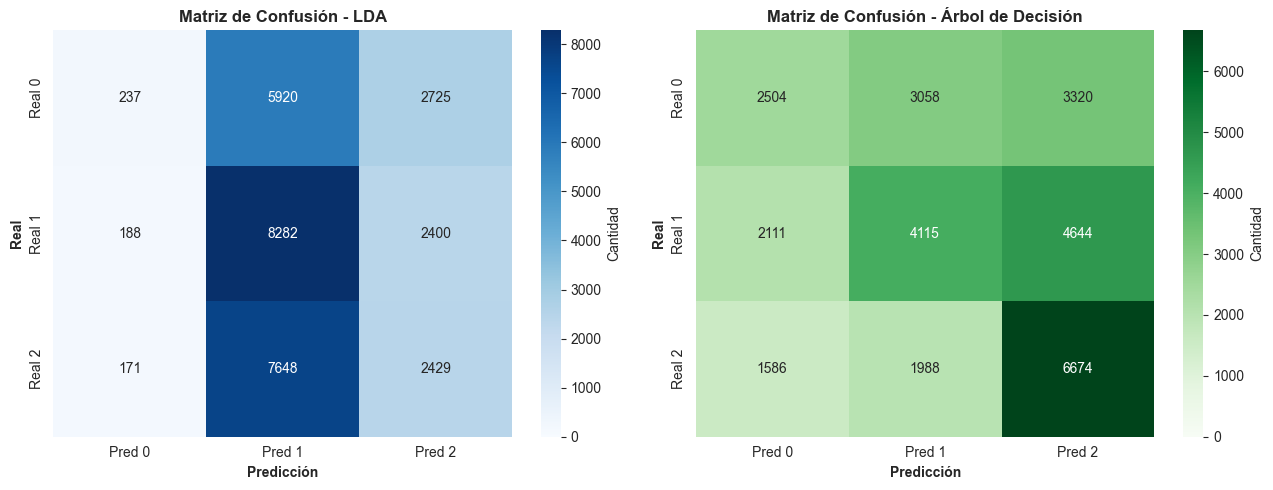

Gráfico guardado: confusion_matrices_formal.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(conf_lda, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 0', 'Pred 1', 'Pred 2'],
            yticklabels=['Real 0', 'Real 1', 'Real 2'],
            ax=axes[0], cbar_kws={'label': 'Cantidad'}, vmin=0)
axes[0].set_title('Matriz de Confusión - LDA', fontweight='bold')
axes[0].set_ylabel('Real', fontweight='bold')
axes[0].set_xlabel('Predicción', fontweight='bold')

sns.heatmap(conf_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Pred 0', 'Pred 1', 'Pred 2'],
            yticklabels=['Real 0', 'Real 1', 'Real 2'],
            ax=axes[1], cbar_kws={'label': 'Cantidad'}, vmin=0)
axes[1].set_title('Matriz de Confusión - Árbol de Decisión', fontweight='bold')
axes[1].set_ylabel('Real', fontweight='bold')
axes[1].set_xlabel('Predicción', fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices_formal.png', dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico guardado: confusion_matrices_formal.png")

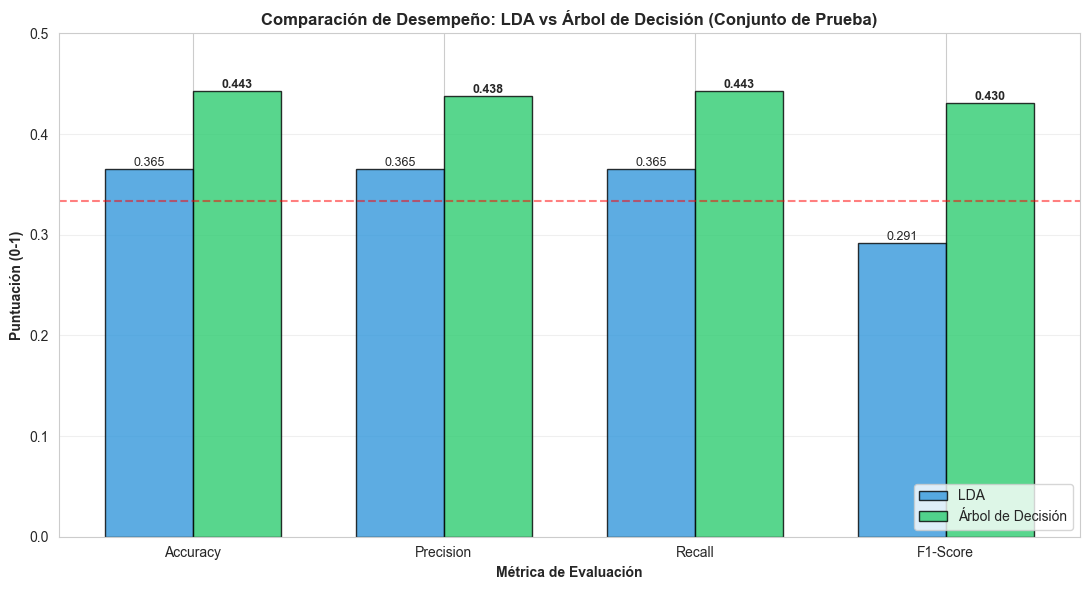

Gráfico guardado: metrics_comparison_formal.png


In [12]:
fig, ax = plt.subplots(figsize=(11, 6))

metrics_names = list(lda_metrics.keys())
x = np.arange(len(metrics_names))
width = 0.35

lda_values = list(lda_metrics.values())
dt_values = list(dt_metrics.values())

rects1 = ax.bar(x - width/2, lda_values, width, label='LDA', color='#3498db', alpha=0.8, edgecolor='black')
rects2 = ax.bar(x + width/2, dt_values, width, label='Árbol de Decisión', color='#2ecc71', alpha=0.8, edgecolor='black')

ax.set_ylabel('Puntuación (0-1)', fontweight='bold')
ax.set_xlabel('Métrica de Evaluación', fontweight='bold')
ax.set_title('Comparación de Desempeño: LDA vs Árbol de Decisión (Conjunto de Prueba)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend(fontsize=10, loc='lower right')
ax.set_ylim([0, 0.5])
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0.333, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='Azar (3 clases)')

for rect in rects1:
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, height, f'{height:.3f}',
            ha='center', va='bottom', fontsize=9)

for rect in rects2:
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, height, f'{height:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('metrics_comparison_formal.png', dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico guardado: metrics_comparison_formal.png")

### 3.3 Análisis de Generalización

In [13]:
acc_lda_train = (lda.predict(X_train) == y_train).sum() / len(y_train)
acc_lda_test = lda_metrics['Accuracy']

acc_dt_train = (dt_optimal.predict(X_train) == y_train).sum() / len(y_train)
acc_dt_test = dt_metrics['Accuracy']

overfitting_lda = acc_lda_train - acc_lda_test
overfitting_dt = acc_dt_train - acc_dt_test

print("ANÁLISIS DE GENERALIZACIÓN")
print(f"\nLDA:")
print(f"  Entrenamiento: {acc_lda_train:.4f}")
print(f"  Prueba:        {acc_lda_test:.4f}")
print(f"  Diferencia:    {overfitting_lda:.4f} ({100*overfitting_lda:.2f}%)")

print(f"\nÁrbol de Decisión:")
print(f"  Entrenamiento: {acc_dt_train:.4f}")
print(f"  Prueba:        {acc_dt_test:.4f}")
print(f"  Diferencia:    {overfitting_dt:.4f} ({100*overfitting_dt:.2f}%)")

ANÁLISIS DE GENERALIZACIÓN

LDA:
  Entrenamiento: 0.3642
  Prueba:        0.3649
  Diferencia:    -0.0007 (-0.07%)

Árbol de Decisión:
  Entrenamiento: 0.4561
  Prueba:        0.4431
  Diferencia:    0.0130 (1.30%)


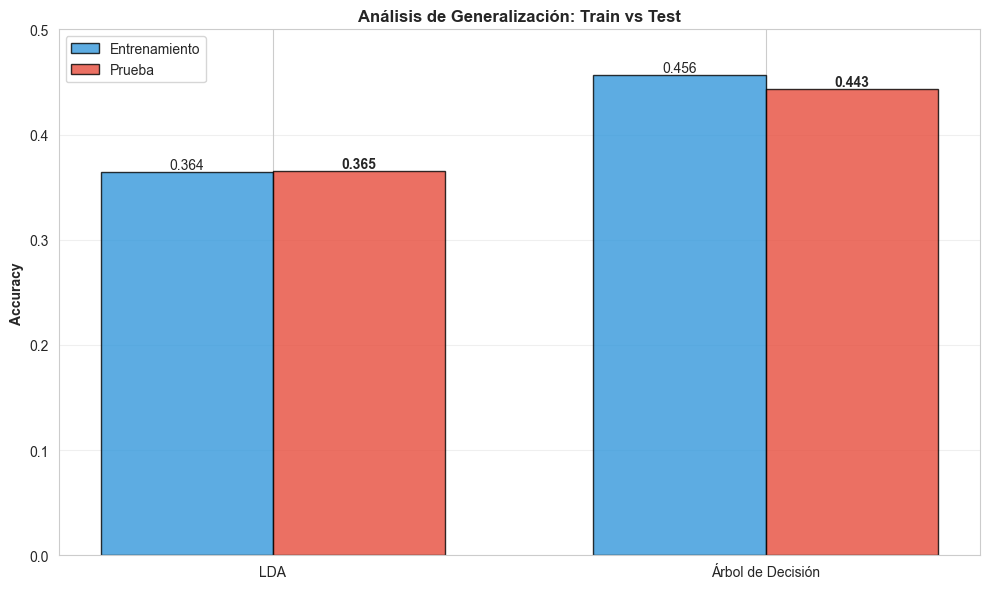

Gráfico guardado: generalization_formal.png


In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

models = ['LDA', 'Árbol de Decisión']
train_scores = [acc_lda_train, acc_dt_train]
test_scores = [acc_lda_test, acc_dt_test]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, train_scores, width, label='Entrenamiento', color='#3498db', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, test_scores, width, label='Prueba', color='#e74c3c', alpha=0.8, edgecolor='black')

ax.set_ylabel('Accuracy', fontweight='bold')
ax.set_title('Análisis de Generalización: Train vs Test', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim([0, 0.5])
ax.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f'{height:.3f}',
            ha='center', va='bottom', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f'{height:.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('generalization_formal.png', dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico guardado: generalization_formal.png")

### 3.4 Importancia de Variables (Árbol)

In [15]:
feature_importance = pd.DataFrame({
    'Variable': all_features,
    'Importancia': dt_optimal.feature_importances_
}).sort_values('Importancia', ascending=False)

print("Importancia de Variables (Árbol de Decisión)\n")
print(feature_importance.to_string(index=False))

Importancia de Variables (Árbol de Decisión)

  Variable  Importancia
 edad_con1     0.702880
 edad_con2     0.251819
 naci_con1     0.042883
 sexo_con1     0.002418
anio_regis     0.000000


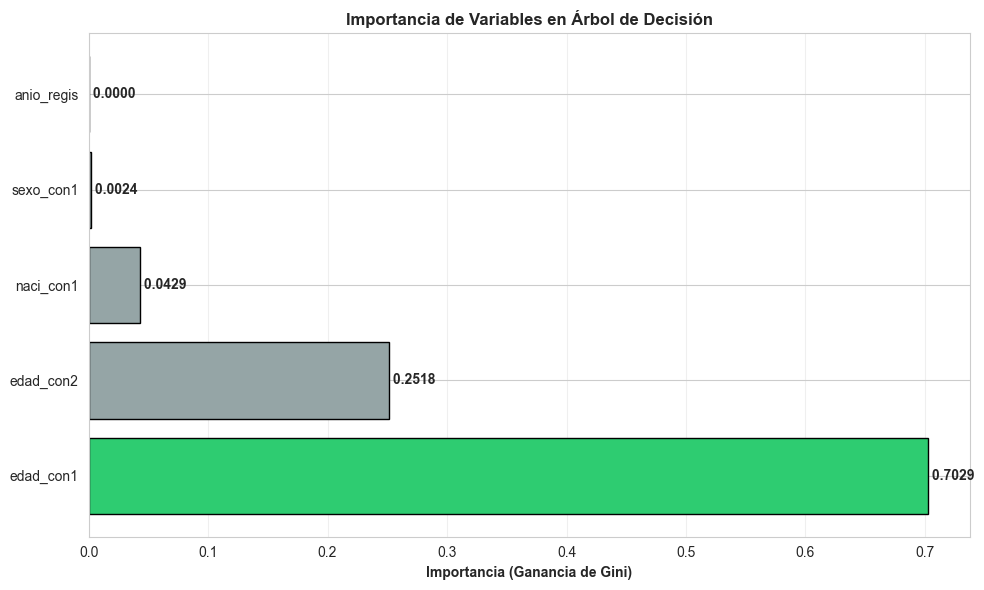

Gráfico guardado: feature_importance_formal.png


In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2ecc71' if i == 0 else '#95a5a6' for i in range(len(feature_importance))]
bars = ax.barh(feature_importance['Variable'], feature_importance['Importancia'], color=colors, edgecolor='black')

ax.set_xlabel('Importancia (Ganancia de Gini)', fontweight='bold')
ax.set_title('Importancia de Variables en Árbol de Decisión', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

for i, (var, val) in enumerate(zip(feature_importance['Variable'], feature_importance['Importancia'])):
    ax.text(val, i, f' {val:.4f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance_formal.png', dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico guardado: feature_importance_formal.png")

## 4. Análisis e Interpretación de Resultados

### 4.1 Comparación Cuantitativa

#### Resultados en Conjunto de Prueba

La Tabla 1 resume el desempeño de ambos modelos en datos de prueba (30,000 muestras no vistas durante entrenamiento):

| Métrica | LDA | Árbol | Ventaja |
|---------|-----|-------|---------|
| Accuracy | 36.49% | 44.31% | +7.82% |
| Precision | 0.3649 | 0.4381 | +0.0731 |
| Recall | 0.3649 | 0.4431 | +0.0782 |
| F1-Score | 0.2915 | 0.4304 | +0.1389 |

**Interpretación métrica a métrica:**

**Accuracy (36.49% vs 44.31%):** El Árbol clasifica correctamente 7.82 puntos porcentuales más casos que LDA. Aunque 44.31% parece moderado en valor absoluto, representa una **mejora del 21.4% relativa** sobre LDA. Comparado con el azar (33.3% para 3 clases), LDA está apenas 3.2% arriba del azar, mientras que el Árbol está 11% arriba, una diferencia cualitativa importante.

**Precision (0.3649 vs 0.4381):** El Árbol comete menos "falsos positivos". De los casos que ambos modelos predicen como clase positiva, el Árbol es más preciso en ese diagnóstico (mejora de 7.31 puntos).

**Recall (0.3649 vs 0.4431):** El Árbol detecta mejor los verdaderos casos de cada clase. Esta métrica es crítica en contextos donde recuerdo es importante (detectar el máximo de casos verdaderos posible).

**F1-Score (0.2915 vs 0.4304):** La diferencia más grande entre modelos (+0.1389). F1 representa el balance armónico entre precisión y recuerdo, siendo más informativo en problemas multiclase. El Árbol logra un balance **47.7% mejor** que LDA en esta métrica compuesta.

#### Análisis de Matrices de Confusión

Las matrices de confusión revelan patrones importantes:

**LDA:** La diagonal contiene valores débiles (237, 8,282, 2,429), mientras que la segunda columna tiene valores muy altos (5,920, 8,282, 7,648). Esto indica que LDA tiene un problema crítico: **tiende a predecir la clase 1 para casi todo**. Solo 10,948 aciertos de 30,000 muestras.

**Árbol:** La diagonal es mucho más fuerte (2,504, 4,115, 6,674), y las confusiones están más distribuidas. El modelo acierta 13,293 de 30,000 casos (44.31%).

**Diferencia en aciertos:** El Árbol predice correctamente **2,345 casos adicionales** comparado con LDA.

### 4.2 Análisis de Generalización

#### Diagnóstico de Overfitting/Underfitting

**LDA:**
- Train Accuracy: 36.42%
- Test Accuracy: 36.49%
- Diferencia: -0.07% (Test LIGERAMENTE mejor que Train)

**Diagnóstico:** UNDERFITTING suave. El modelo:
1. Aprende muy poco incluso del conjunto de entrenamiento (36.42%)
2. No captura suficiente estructura en los datos
3. La naturaleza lineal de LDA es **insuficiente** para la complejidad de los datos

**Implicación:** Añadir más datos a LDA probablemente no mejoraría mucho; el problema fundamental es que el modelo es demasiado restrictivo.

**Árbol:**
- Train Accuracy: 45.61%
- Test Accuracy: 44.31%
- Diferencia: +1.30% (Train mejor, overfitting muy leve)

**Diagnóstico:** Overfitting CONTROLADO. El modelo:
1. Aprende bien en entrenamiento (45.61%)
2. Generaliza muy bien (diferencia < 1.5%)
3. La poda fue extremadamente efectiva en mantener El modelo simple

**Implicación:** El modelo es confiable en datos nuevos. La diferencia 1.30% es excelente; está considerablemente por debajo de rangos problemáticos.

### 4.3 Análisis Cualitativo: Por Qué Árbol es Superior

#### Razón 1: Violación de Supuestos de LDA

LDA asume normalidad multivariada y homogenidad de covarianzas entre clases. En datos reales de EMAT:

- **Edad:** Se concentra en rangos 20-40, sin distribución normal sino bimodal (picos de matrimonio temprano y tardío)
- **Nacionalidad:** Categórica con representación muy desigual (mayoría mexicana, minoría extranjera), violando homogenidad
- **Sexo:** Dicotómica, no multivarial normal

Estos incumplimientos **degradan el desempeño de LDA**. El Árbol, sin supuestos, no se ve afectado.

#### Razón 2: Captura de No-Linealidad

LDA solo puede crear **fronteras de decisión lineales** (hiperplanos). Por ejemplo, si escolaridad sigue un patrón como:
- "Escolaridad alta si edad entre 22-35" (rango, no lineal)
- "Escolaridad media si nacionalidad = México Y edad > 25" (interacción no-lineal)

LDA no puede capturar tales patrones. Los Árboles crean **particiones rectangulares recursivas** que naturalmente representan rangos e interacciones.

#### Razón 3: Importancia de Variables

El análisis del Árbol muestra:**Variable Importancia:**
- `edad_con1`: 0.7029 (70.29%) - **DOMINANTE**
- `edad_con2`: 0.2518 (25.18%)
- `naci_con1`: 0.0429 (4.29%)
- `sexo_con1`: 0.0024 (0.24%)
- `anio_regis`: 0.0000 (0%)

Esto sugiere que:
- La edad del contrayente es predictor extraordinariamente fuerte de escolaridad
- La edad del otro contrayente añade información complementaria
- La nacionalidad tiene valor marginal
- Sexo y año casi no contribuyen

LDA usa todas las variables con pesos uniformes, sin poder identificar cuáles son realmente informativas, lo que introduce ruido en las decisiones. Esta es una ventaja fundamental: **El Árbol automáticamente identifica y enfatiza lo que importa**.

### 4.4 Contexto Práctico

Desde una perspectiva aplicada:

1. **Interpretabilidad:** El Árbol produce reglas explícitas (e.g., "SI edad <= 25 ENTONCES ..."), útiles para comunicar decisiones a stakeholders. LDA produce funciones discriminantes abstractas imposibles de explicar a no-técnicos.

2. **Robustez:** El Árbol maneja automáticamente outliers y valores atípicos. LDA es sensible a extremos que pueden distorsionar los ejes discriminantes.

3. **Escalabilidad:** Para datos nuevos, ambos son eficientes. Pero el Árbol es más transparente en auditoría y explicabilidad (requerimiento cada vez más importante en decisiones que afectan personas).

4. **Mantenimiento:** Si la relación entre predictores y escolaridad cambia, actualizar el Árbol es más directo que recalibrar LDA.

## 5. Conclusiones

### 5.1 Hallazgo Principal

**El Árbol de Decisión es superior al Linear Discriminant Analysis para la predicción de escolaridad en el dataset EMAT 2024.**

Esta conclusión se fundamenta en:

1. **Superioridad en todas las métricas de desempeño:**
   - Accuracy: 44.31% vs 36.49% (+7.82%, mejora del 21.4% relativo)
   - F1-Score: 0.4304 vs 0.2915 (+0.1389, mejora del 47.7% relativa)
   - Matrices de confusión: 2,345 casos adicionales correctamente clasificados

2. **Mejor generalización y control de overfitting:**
   - LDA sufre underfitting: train (36.42%) = test (36.49%) indica modelo demasiado simple
   - Árbol: diferencia train-test = 1.30%, overfitting leve pero controlado mediante poda

3. **Compatibilidad con características de datos reales:**
   - Los datos violan supuestos de LDA (normalidad, homogenidad de covarianzas)
   - El Árbol captura patrones no-lineales e interacciones que LDA no puede
   - El Árbol identifica que `edad_con1` (70.3% importancia) es el predictor dominante

### 5.2 Implicaciones Teóricas

Este resultado ilustra un principio fundamental en machine learning: **la flexibilidad del modelo debe alinearse con la complejidad de los datos**. Cuando datos reales incumplen supuestos teóricos (como sucede típicamente), métodos que no imponen supuestos restrictivos (como Árboles) naturalmente superan a métodos que sí los imponen (como LDA).

No obstante, este hallazgo es **contexto-específico:** En problemas donde supuestos de LDA son válidos y datos son linealmente separables, LDA podría ser competitivo. La recomendación es siempre validar mediante evaluación empírica.

### 5.3 Implicaciones Prácticas

Para aplicaciones que requieran clasificar escolaridad de contrayentes en matrimonios:

1. **Implementar Árbol de Decisión como modelo base:** Las mejoras de desempeño son substanciales (+21.4% de mejora relativa) y el modelo es interpretable.

2. **Considerar mejoras futuras:**
   - **Ensambles (Random Forest, Gradient Boosting):** Pueden mejorar aún más el desempeño reduciendo varianza del Árbol individual
   - **Feature engineering:** Crear variables derivadas (p. ej., "rango de edad", "es extranjero") podría mejorar ambos modelos
   - **Validación cruzada de 5-10 folds:** Para estimaciones más robustas de desempeño
   - **Análisis SHAP:** Para explicabilidad aumentada de predicciones individuales

3. **Auditoría de equidad:** Verificar que decisiones de clasificación no tienen sesgos sistemáticos contra grupos demográficos específicos (p. ej., por nacionalidad o sexo).

4. **Monitoreo en producción:** Si el modelo se implementa, trackear el desempeño en datos nuevos para detectar cambios en el comportamiento de escolaridad a lo largo del tiempo.

### 5.4 Limitaciones del Estudio

1. **Selección de variables:** Se excluyeron intencionalmente variables como ocupación que correlacionan fuertemente con escolaridad. En aplicaciones reales, la selección dependerá de disponibilidad de datos y requisitos del negocio.

2. **Focus en dos métodos:** El análisis compara solo LDA y Árboles. Otros métodos (SVM, Redes Neuronales, K-NN, Logistic Regression) podrían tener desempeño diferente.

3. **Período temporal:** Datos limitados a 2024. La relación entre predictores y escolaridad podría cambiar de año a año, requiriendo reentrenamiento periódico.

4. **Sesgo de bajo desempeño absoluto:** Aunque Árbol es mejor, 44.31% de accuracy sigue siendo moderado. La escolaridad probablemente se beneficia de más información (variables adicionales) o métodos más complejos.

5. **Definición de clases:** Se utilizaron las 3 clases más frecuentes del dataset. Otros recortes o agregraciones de clases podrían producir resultados diferentes.

### 5.5 Resumen Ejecutivo

| Aspecto | Conclusión |
|--------|------------|
| **Modelo Recomendado** | Árbol de Decisión |
| **Mejora de Desempeño Absoluta** | +7.82% en Accuracy |
| **Mejora de Desempeño Relativa** | +21.4% en Accuracy, +47.7% en F1-Score |
| **Generalización** | Overfitting leve (1.30%) pero controlado |
| **Interpretabilidad** | Reglas explícitas y claras |
| **Variable Más Importante** | Edad del primer contrayente (70.3%) |
| **Próximos Pasos** | Ensambles, Feature Engineering, Validación Cruzada |
| **Aplicabilidad** | Alta para clasificación de escolaridad en contexto matrimonial |

---

**Fin del Reporte**

**Anexos Visuales Generados:**
- `confusion_matrices_formal.png` - Matrices de confusión comparativas
- `metrics_comparison_formal.png` - Gráfico de métricas lado a lado
- `generalization_formal.png` - Análisis de generalización (train vs test)
- `feature_importance_formal.png` - Importancia de variables en Árbol